In [ ]:
import pandas as pd
import numpy as np
import sklearn
import shap
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

# **Load data**

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/AIO_Warm Up_REVIEW/AIO_The Liems/CONQ023/CONQ23_project/data/processed/df_train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/AIO_Warm Up_REVIEW/AIO_The Liems/CONQ023/CONQ23_project/data/processed/df_test.csv')

In [ ]:
df_train.head()

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag,Attrition
0,47.0,2,2,2.0,4.0,1,2.0,0,4.0,4.0,...,2.0,3.0,3.0,2.0,1.0,2.0,0.1017,339.83,0.0,0
1,22.0,2,1,2.0,1.0,5,3.0,1,3.0,1.0,...,2.0,3.0,2.0,1.0,2.0,1.0,0.5000,114.68,1.0,0
2,46.0,2,2,3.0,1.0,2,1.0,1,3.0,4.0,...,3.0,3.0,12.0,9.0,4.0,9.0,0.5000,379.67,0.0,0
3,25.0,2,2,13.0,1.0,3,2.0,1,3.0,1.0,...,1.0,3.0,7.0,4.0,0.0,6.0,0.8750,83.84,0.0,0
4,43.0,1,1,9.0,5.0,3,4.0,1,3.0,2.0,...,3.0,3.0,8.0,7.0,4.0,7.0,0.7273,132.07,0.0,0


In [ ]:
X_train = df_train.drop('Attrition', axis=1)
y_train = df_train.Attrition
X_test = df_test.drop('Attrition', axis=1)
y_test = df_test.Attrition

# **A. Huấn luyện mô hình LogisticRegression**

- `penalty="l2"`: Tham số này xác định loại hình phạt (regularization) được áp dụng. 'l2' là một kỹ thuật được sử dụng để ngăn chặn overfitting (quá khớp) bằng cách thêm một số hạng vào hàm mất mát (loss function) tỷ lệ với bình phương của độ lớn các hệ số của mô hình. Điều này giúp giữ cho các hệ số nhỏ và tránh các biến trở nên quá ảnh hưởng.
- `C=0.1`: Đây là nghịch đảo của cường độ điều hòa (regularization strength). Các giá trị nhỏ hơn của C chỉ ra cường độ điều hòa mạnh hơn, điều này có nghĩa là mô hình sẽ bị phạt nhiều hơn nếu các hệ số của nó lớn.

- `max_iter=1000`: Tham số này đặt số lần lặp tối đa mà thuật toán giải phải chạy để hội tụ (converge). Nếu thuật toán không hội tụ trong 1000 lần lặp, nó sẽ dừng lại. Điều này thường được sử dụng để kiểm soát thời gian huấn luyện và tránh các vòng lặp vô hạn.

In [ ]:
# 1. Khởi tạo mô hình
black_box_lr = LogisticRegression(penalty="l2", C=0.1, max_iter=1000, random_state=42)

# 2. Huấn luyện mô hình với tập train
black_box_lr.fit(X_train, y_train)

# 3. Dự đoán và đánh giá trên tập test
y_pred = black_box_lr.predict(X_test)
print("Báo cáo kết quả mô hình Logistic Regression:")
print(classification_report(y_test, y_pred))

Báo cáo kết quả mô hình Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       247
           1       0.38      0.62      0.47        47

    accuracy                           0.78       294
   macro avg       0.65      0.71      0.67       294
weighted avg       0.83      0.78      0.80       294



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Giải thích mô hình Logistic Regression bằng Kernel SHAP

In [ ]:
# Define the prediction function for the logistic regression model
def predict_proba_lr(X):
    return black_box_lr.predict_proba(X)

# For Kernel SHAP, we often need a background dataset. A common approach is to sample from the training data.
# Let's use a small sample from X_train as the background dataset.
X_train_sampled = shap.utils.sample(X_train, 100)

# Initialize the Kernel SHAP explainer
explainer_lr = shap.KernelExplainer(predict_proba_lr, X_train_sampled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Chúng ta sẽ tính toán giá trị SHAP cho xác suất của lớp tích cực (lớp 1).
shap_values = explainer_lr.shap_values(X_test)

  0%|          | 0/294 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist

/tmp/ipykernel_1198/174455735.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test)


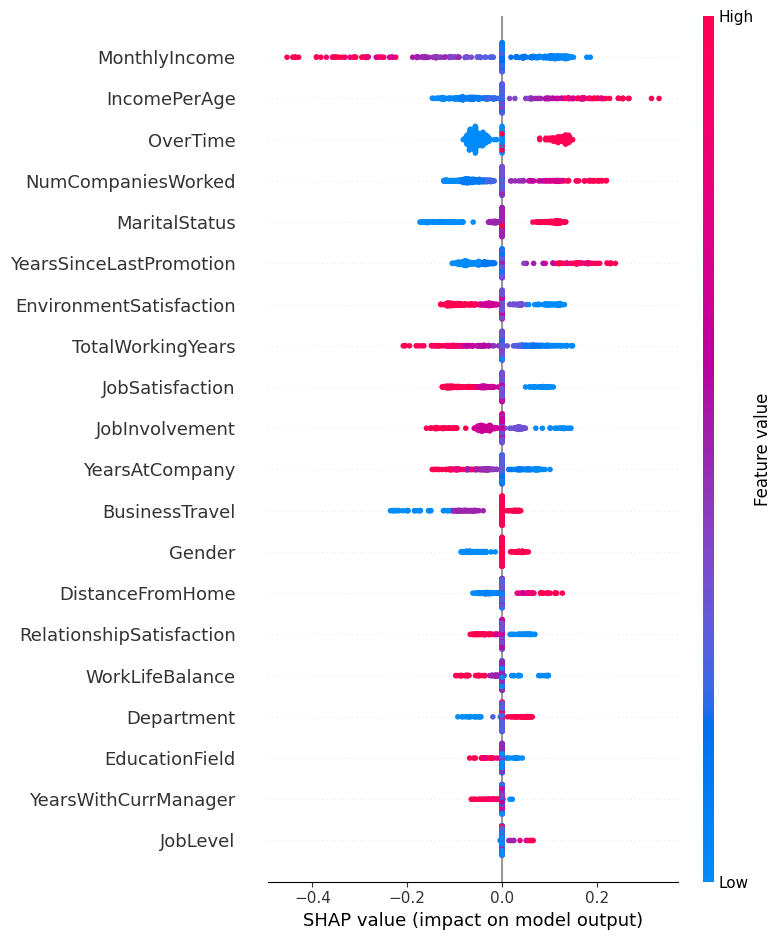

In [ ]:
# Visualize the SHAP values using a summary plot
shap.summary_plot(shap_values[:, :, 1], X_test)

# **B. Huấn luyện  mô hình Random Forest**

`n_estimators=100`: Tham số này chỉ định số lượng cây quyết định sẽ được xây dựng trong rừng. Việc sử dụng 100 cây thường là một lựa chọn hợp lý để có sự cân bằng giữa hiệu suất mô hình và chi phí tính toán.

In [ ]:
# 1. Khởi tạo mô hình Random Forest
black_box_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Huấn luyện mô hình
black_box_rf.fit(X_train, y_train)

# 3. Dự đoán và đánh giá
y_pred_rf = black_box_rf.predict(X_test)
print("Báo cáo kết quả mô hình Random Forest:")
print(classification_report(y_test, y_pred_rf))

Báo cáo kết quả mô hình Random Forest:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       247
           1       0.44      0.26      0.32        47

    accuracy                           0.83       294
   macro avg       0.66      0.60      0.61       294
weighted avg       0.80      0.83      0.81       294



## Giải thích mô hình Random Forest bằng Tree SHAP

In [ ]:
# 1. Khởi tạo TreeExplainer cho mô hình Random Forest
explainer_rf = shap.TreeExplainer(black_box_rf)

# 2. Tính toán giá trị SHAP cho tập test
# Đối với Random Forest trong sklearn, shap_values trả về một list cho mỗi class
shap_values_rf = explainer_rf.shap_values(X_test)

/tmp/ipykernel_1198/4215386835.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_rf[:, :, 1], X_test)


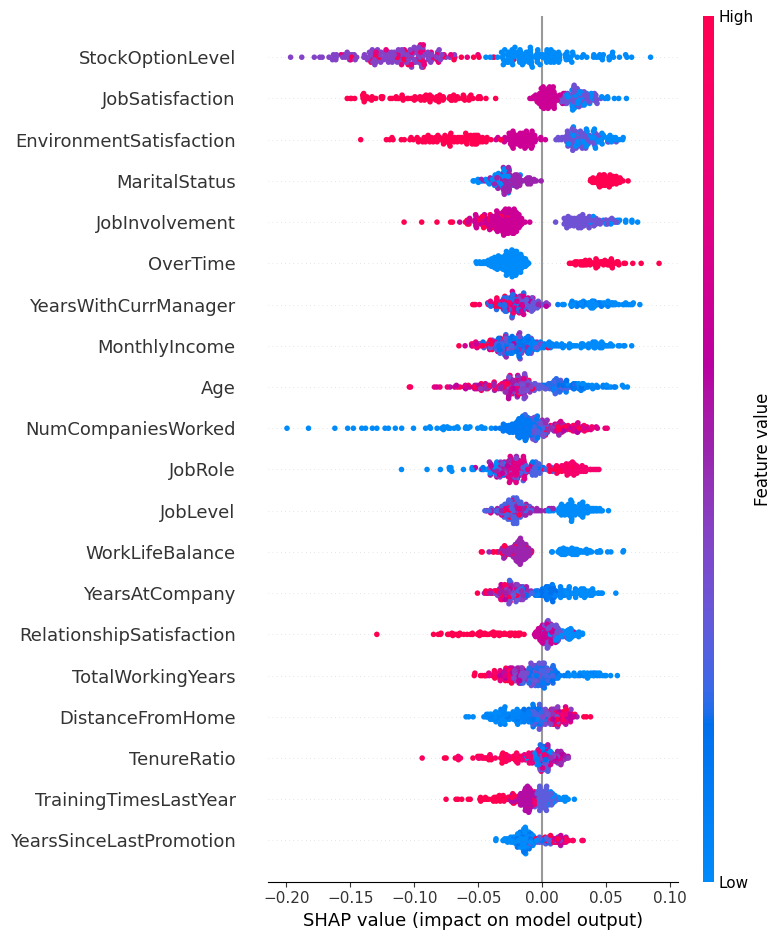

In [ ]:
# 3. Trực quan hóa bằng summary plot cho lớp positive (Attrition = 1)
# Lưu ý: Trong các phiên bản SHAP mới, shap_values cho RF có thể trả về array 3D hoặc list 2D.
# Chúng ta chọn index [1] để xem giải thích cho việc nhân viên nghỉ việc.
if isinstance(shap_values_rf, list):
    shap.summary_plot(shap_values_rf[1], X_test)
else:
    shap.summary_plot(shap_values_rf[:, :, 1], X_test)